# Week 3 — Linear Regression: NESA Course Specification

**Software Engineering Year 12 | HSC**

---

## Overview

In this notebook you will implement the NESA linear regression algorithm step by step.  
The scenario uses a simple, clearly linear dataset so you can focus on *what the code does* rather than debugging complex data.

**Scenario:** You work for a city council analysing summer sales data.  
You have records of the daily maximum temperature (°C) and the number of ice cream units sold at a beachside kiosk.  
**Goal:** Train a linear regression model that predicts ice cream sales from temperature.

---

## Before you begin

Make sure you have answered the pre-notebook question in Stile before running any cells.

Work through each step in order. **Do not skip the reflection questions** — answer them in the Markdown cells provided.  
You must push your completed notebook to GitHub Classroom before the end of the session.

---

## Tiered challenges (attempt if you finish early)

- **Core:** Complete Steps 1–9 and answer all embedded questions.
- **Extended:** Add two new data points to the dataset and re-run all cells. Describe what changes.
- **Advanced:** Manually calculate the mean squared error (MSE) for one training example.

---
## Dataset Setup

Run the cell below to create the dataset. This step is provided for you — read it carefully before running.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Ice cream sales dataset
# Each row: one day of observations
# temperature = daily maximum temperature in degrees Celsius
# sales       = ice cream units sold at the beachside kiosk

data = pd.DataFrame({
    'temperature': [10, 14, 18, 21, 24, 27, 29, 31, 34, 37, 40, 44, 47],
    'sales':       [125, 178, 220, 295, 370, 440, 490, 525, 595, 645, 632, 489, 211]
})

print(data)
print(f"\nDataset shape: {data.shape[0]} rows × {data.shape[1]} columns")

    temperature  sales
0            10    125
1            14    178
2            18    220
3            21    295
4            24    370
5            27    440
6            29    490
7            31    525
8            34    595
9            37    645
10           40    632
11           44    489
12           47    211

Dataset shape: 13 rows × 2 columns


---
### 📝 Reflection 0 — Inspect the Data

> **Answer this question in the cell below before continuing.**
>
> (a) Which column is the **feature** (X) and which is the **target** (y)?  
> (b) Do the values in the table suggest a positive or negative relationship?  
> (c) Estimate the slope by eye: roughly how many extra units are sold per extra degree of temperature?

**Your answer (double-click to edit):**

(a) Feature (X): Temperature 
    Target (y): Sales

(b) Relationship: Positive; I can see that sales generally increase as temperature increases.

(c) Estimated slope: Roughly 16 units per °C because I averaged the rise/run between the data points

---
## Step 1 — Import the Algorithm

Load the `LinearRegression` class from scikit-learn's `linear_model` module.

> **Why this step?**  
> scikit-learn is a Python library that provides pre-built ML algorithm classes.  
> `from sklearn.linear_model import LinearRegression` loads just the class we need —  
> not the entire scikit-learn library. This is the OOP pattern: importing a class first.

In [17]:
# Step 1: Import the LinearRegression class
from sklearn.linear_model import LinearRegression

print("LinearRegression imported successfully.")

LinearRegression imported successfully.


---
## Step 2 — Separate Features and Targets

Extract the input feature column (X) and the output target column (y) from the DataFrame.

> **Why this step?**  
> The algorithm needs to know which column to *use* as input (feature)  
> and which column to *learn to predict* (target). We separate them explicitly.

In [18]:
# Step 2: Separate features and targets
X = data['temperature']   # input feature: temperature in °C
y = data['sales']         # target: ice cream units sold

print(f"Feature (X): {X.values}")
print(f"Target (y):  {y.values}")

Feature (X): [10 14 18 21 24 27 29 31 34 37 40 44 47]
Target (y):  [125 178 220 295 370 440 490 525 595 645 632 489 211]


---
## Step 3 — Reshape the Feature Array

Convert X from a 1D array (flat list) to a 2D array (table with rows and columns).

> **Why this step?**  
> scikit-learn's `LinearRegression` expects X to be a 2D array: one row per sample,  
> one column per feature. A pandas Series is 1D. The `.reshape(-1, 1)` adds the  
> column dimension: `[10, 14, 18, ...]` becomes `[[10], [14], [18], ...]`.  
> The `-1` tells NumPy to calculate the number of rows automatically.

In [19]:
# Step 3: Reshape X to a 2D array
X = X.values.reshape(-1, 1)

print(f"Shape of X after reshape: {X.shape}")
print(f"First 3 rows of X: {X[:3]}")

Shape of X after reshape: (13, 1)
First 3 rows of X: [[10]
 [14]
 [18]]


---
### 📝 Reflection 3 — Reshape

> The `.shape` of X after reshaping should be `(10, 1)` — 10 rows, 1 column.
>
> (a) What was the shape of X *before* reshaping (i.e. when it was just a pandas Series)?  
> (b) Why does scikit-learn require a 2D array rather than a 1D list?  
>     (Hint: think about what would change if we had *two* features instead of one.)

**Your answer:**

(a) Before reshape: *shape was ...*

(b) Reason for 2D: *...

---
## Step 4 — Instantiate the Model

Create a `LinearRegression` object. This sets up the model structure with default parameters.

> **Why this step?**  
> Instantiation (creating an object from a class) is Step 1 of the OOP pattern.  
> At this point, the model exists as an object in memory but has not seen any data.  
> It has no slope or intercept yet — those are determined in Step 5.

In [20]:
# Step 4: Instantiate the model
model = LinearRegression()

print("Model created:", model)
print("Has the model been trained yet? No — .fit() has not been called.")

Model created: LinearRegression()
Has the model been trained yet? No — .fit() has not been called.


---
## Step 5 — Fit (Train) the Model

Train the model on the data. This is where machine learning happens.

> **Why this step?**  
> `.fit(X, y)` passes the training data to the algorithm.  
> The algorithm calculates the values of slope (m) and intercept (b) that minimise  
> the total squared error between the line's predictions and the actual sales values.  
> After this step, the model has "learned" from the data.

In [21]:
# Step 5: Fit the model to the training data
model.fit(X, y)

print("Training complete.")
print("The model has now learned slope and intercept values from the data.")

Training complete.
The model has now learned slope and intercept values from the data.


---
## Step 6 — Retrieve the Slope and Intercept

After training, inspect what the algorithm discovered.

> **Why this step?**  
> `model.coef_` gives the slope (m): how much sales change per 1°C increase.  
> `model.intercept_` gives the y-intercept (b): the predicted sales at 0°C.  
> These two values fully define the line: **y = m × x + b**

In [22]:
# Step 6: Retrieve and display the slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m):      {slope:.2f}")
print(f"Intercept (b):  {intercept:.2f}")
print(f"\nModel equation: y = {slope:.2f}x + {intercept:.2f}")
print(f"In context: sales = {slope:.2f} × temperature + {intercept:.2f}")

Slope (m):      9.67
Intercept (b):  121.42

Model equation: y = 9.67x + 121.42
In context: sales = 9.67 × temperature + 121.42


---
### 📝 Reflection 6 — Interpreting the Equation

> (a) Does the slope value make sense for this scenario?  
>     For every 1°C increase in temperature, how many extra ice creams does the model predict?  
> (b) What does the y-intercept represent in this context?  
>     Is it physically meaningful for ice cream sales?  
> (c) Compare the algorithm's slope to your estimate in Reflection 0(c). Were you close?

**Your answer:**

(a) The slope means: *...*

(b) The intercept means: *...* | Physically meaningful? *Yes/No because ...*

(c) My estimate was ___ vs the algorithm's ___. *...*

---
## Step 7 — Visualise the Training Data

Plot the original data points as a scatter plot.

> **Why this step?**  
> Visualising the data before overlaying the model line helps you judge whether  
> a linear fit is appropriate. If the data forms a clear straight-line pattern,  
> linear regression is a good choice.

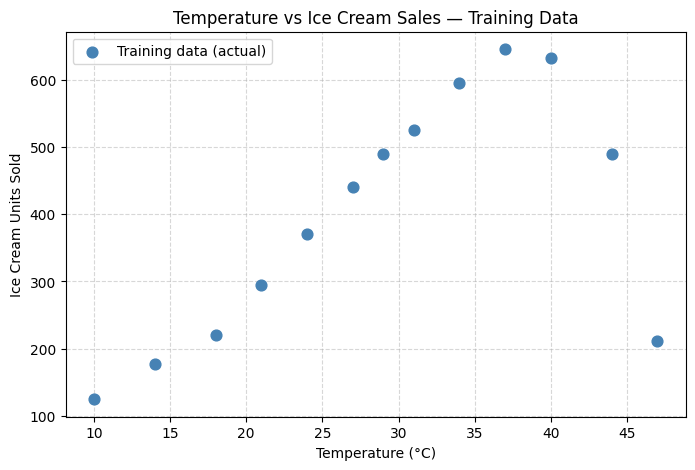

In [23]:
# Step 7: Visualise the training data as a scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', s=60, label='Training data (actual)', zorder=3)
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Units Sold')
plt.title('Temperature vs Ice Cream Sales — Training Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## Step 8 — Make Predictions

Use the trained model to generate predicted sales values for all training temperatures.

> **Why this step?**  
> `.predict(X)` applies the learned equation (y = mx + b) to every row of X,  
> returning a predicted sales value for each temperature.  
> These predicted values form the regression line when plotted.

In [24]:
# Step 8: Use the model to make predictions
y_pred = model.predict(X)

# Display actual vs predicted for each data point
comparison = pd.DataFrame({
    'Temperature (°C)': data['temperature'],
    'Actual sales':     data['sales'],
    'Predicted sales':  y_pred.round(1)
})
print(comparison.to_string(index=False))

 Temperature (°C)  Actual sales  Predicted sales
               10           125            218.1
               14           178            256.8
               18           220            295.5
               21           295            324.5
               24           370            353.5
               27           440            382.6
               29           490            401.9
               31           525            421.2
               34           595            450.3
               37           645            479.3
               40           632            508.3
               44           489            547.0
               47           211            576.0


---
### 📝 Reflection 8 — Predicted vs Actual

> (a) Look at the comparison table above.  
>     Find the row where the difference between actual and predicted sales is largest.  
>     What temperature is this? What does the gap suggest about the model?
>
> (b) Are the predicted values always exactly equal to the actual values?  
>     Why or why not? (Hint: think about what linear regression is minimising.)

**Your answer:**

(a) Largest gap at temperature: *___°C* | Difference: *___* | This suggests: *...*

(b) *...*

---
## Step 9 — Visualise the Prediction

Overlay the model's regression line on top of the scatter plot.

> **Why this step?**  
> Combining the scatter plot (actual data) with the regression line (predictions)  
> gives an immediate visual check: how well does the model fit the training data?

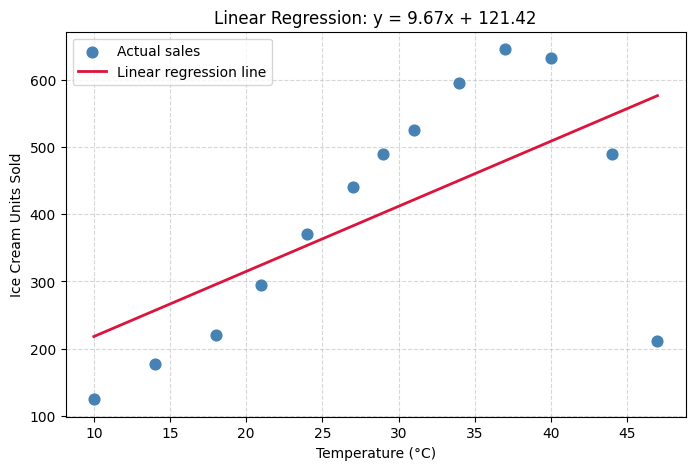

In [25]:
# Step 9: Visualise the prediction — scatter plot + regression line
plt.figure(figsize=(8, 5))

# Plot actual data points
plt.scatter(X, y, color='steelblue', s=60, label='Actual sales', zorder=3)

# Plot the regression line
plt.plot(X, y_pred, color='crimson', linewidth=2, label='Linear regression line')

# Labels and formatting
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Units Sold')
plt.title(f'Linear Regression: y = {slope:.2f}x + {intercept:.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
### 📝 Reflection 9 — Evaluating the Fit

> (a) Does the regression line appear to fit the data well?  
>     Justify your answer with reference to the graph (e.g. how close are the points to the line?)
>
> (b) Use the model to predict sales for a temperature of 40°C.  
>     Run `model.predict([[40]])` in a new cell. Report your answer.  
>     Do you trust this prediction? Explain ONE reason you should be cautious.

**Your answer:**

(a) The fit looks: *good/poor* because *...*

(b) Predicted sales at 40°C: *___* | I would/would not fully trust this because: *...*

In [26]:
# Reflection 9(b): Predict sales at 40°C
prediction_40 = model.predict([[40]])
print(f"Predicted sales at 40°C: {prediction_40[0]:.1f} units")

Predicted sales at 40°C: 508.3 units


---
## ✅ Completion Checklist

Before pushing to GitHub Classroom, confirm:

- [ ] All 9 steps have been run and produced output
- [ ] Reflection 0: answered (features, targets, estimated slope)
- [ ] Reflection 3: answered (reshape rationale)
- [ ] Reflection 6: answered (slope and intercept interpretation)
- [ ] Reflection 8: answered (predicted vs actual comparison)
- [ ] Reflection 9: answered (fit evaluation, 40°C prediction)
- [ ] Notebook is saved and pushed to GitHub Classroom

---

## 🔵 Extended Challenge — Modify the Training Data

*(Attempt this if you have finished the core steps with time to spare.)*

**Task:** Add two new data points to the training dataset and re-run the entire notebook.

Suggested additions (or choose your own):
- Temperature: 40°C, Sales: 680 units
- Temperature: 42°C, Sales: 710 units

After re-running, answer the questions below.

In [27]:
# Extended challenge: Add new data points
# Uncomment and modify the lines below, then re-run from the Dataset Setup cell

# new_temps  = [40, 42]          # add your new temperature values here
# new_sales  = [680, 710]        # add your new sales values here

# data_extended = pd.DataFrame({
#     'temperature': list(data['temperature']) + new_temps,
#     'sales':       list(data['sales'])       + new_sales
# })

# Replace 'data' with 'data_extended' in Steps 2–9 to retrain on the expanded dataset.
print("Uncomment the code above and re-run Steps 2–9 using data_extended.")

Uncomment the code above and re-run Steps 2–9 using data_extended.


**Extended reflection:**

(a) New slope after adding data points: *___* | Changed by: *___*

(b) Did the regression line shift visibly in the Step 9 graph? *Yes/No, because ...*

(c) What does this tell you about the effect of training data on a model? *...*

---
## 🔴 Advanced Challenge — Manual MSE Calculation

*(Attempt this only after completing the Extended challenge.)*

The **Mean Squared Error (MSE)** measures how well the model fits the training data.  
It is calculated by:

1. For each training example: compute `(actual − predicted)²`
2. Average all those squared differences

Formula: **MSE = (1/n) × Σ (yᵢ − ŷᵢ)²**

**Task:** Calculate the MSE manually for the original dataset (without the extended data points).

In [28]:
# Advanced challenge: Manual MSE calculation
# y      = actual sales values (from Step 2)
# y_pred = predicted sales values (from Step 8)

# Step 1: Calculate squared errors for each data point
# squared_errors = (y - y_pred) ** 2

# Step 2: Calculate the mean of the squared errors
# mse_manual = squared_errors.mean()

# Step 3: Verify using scikit-learn's built-in function
# from sklearn.metrics import mean_squared_error
# mse_sklearn = mean_squared_error(y, y_pred)

# print(f"Manual MSE:    {mse_manual:.2f}")
# print(f"sklearn MSE:   {mse_sklearn:.2f}")
# print(f"Do they match? {abs(mse_manual - mse_sklearn) < 0.001}")

print("Uncomment the code above to run the MSE calculation.")

Uncomment the code above to run the MSE calculation.


**Advanced reflection:**

(a) Your calculated MSE: *___*

(b) The MSE is in units of *(sales units)²*. Explain in plain English what a lower MSE means for model quality.

*...*

(c) What is the square root of the MSE called, and why is it sometimes more useful than MSE itself?

*(Hint: RMSE — Root Mean Squared Error)*